# LendingClub PD – Data Wrangling, Outlier Study & Feature Engineering

**Purpose:** Single source of truth for PD (Probability of Default) inputs. We:
1. Load and wrangle LoanStats3a-style data (target definition, missing values, types).
2. Run an **outlier study** (distributions, caps/winsorization) to avoid leakage and stabilize models.
3. Build **15 high-impact features** via `credit_risk.feature_engineering.common_features` (shared by XGBoost and quantum PD models).
4. Save a cleaned, feature-level dataset for downstream training notebooks.

**Data:** Place `LoanStats3a.csv` (or equivalent) under `data/credit_risk_pd/LendingClub/`. Columns expected: `loan_amnt`, `int_rate`, `installment`, `grade`, `emp_length`, `annual_inc`, `dti`, `delinq_2yrs`, `revol_util`, `revol_bal`, `open_acc`, `total_acc`, `inq_last_6mths`, `loan_status`; FICO from `fico_range_low` / `fico_range_high` if present.

## 1. Setup and load raw data

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Repo root (run from repo root or from notebooks/)
ROOT = Path(".").resolve() if (Path(".").resolve() / "credit_risk").exists() else Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data" / "credit_risk_pd" / "LendingClub"
OUTPUT_DIR = DATA_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# LoanStats3a CSV often has 2 header rows and a footer; skipfooter can be used if needed
csv_path = DATA_DIR / "LoanStats3a.csv"
if not csv_path.exists():
    # Fallback: any CSV in folder (e.g. from Kaggle)
    csvs = list(DATA_DIR.glob("*.csv"))
    csv_path = csvs[0] if csvs else None

if csv_path is None or not csv_path.exists():
    raise FileNotFoundError("Place LoanStats3a.csv (or a LendingClub CSV) under data/credit_risk_pd/LendingClub/")

df_raw = pd.read_csv(csv_path, skiprows=1, low_memory=False)
# Remove footer row if present ("Total amount funded" etc.)
df_raw = df_raw[~df_raw.iloc[:, 0].astype(str).str.contains("Total", na=False)]
print(f"Loaded {len(df_raw):,} rows. Columns: {list(df_raw.columns[:20])}...")

Loaded 42,536 rows. Columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']...


## 2. Target definition (binary default)

LendingClub `loan_status` includes: Current, Fully Paid, Charged Off, Late, In Grace Period, etc. We define **default = 1** for Charged Off (and optionally severe delinquency); **non-default = 0** for Fully Paid (and optionally Current). For PD we typically use only **Fully Paid** vs **Charged Off** to avoid censoring.

In [3]:
col_status = "loan_status"
if col_status not in df_raw.columns:
    col_status = [c for c in df_raw.columns if "status" in c.lower()][0] if any("status" in c.lower() for c in df_raw.columns) else None
if col_status is None:
    raise ValueError("No loan_status column found")

df_raw["loan_status"] = df_raw[col_status].astype(str).str.strip()
default_statuses = {"Charged Off", "Default", "charged off", "default"}
paid_statuses = {"Fully Paid", "fully paid", "Current", "current"}

mask_default = df_raw["loan_status"].isin(default_statuses)
mask_paid = df_raw["loan_status"].isin(paid_statuses)
df = df_raw[mask_default | mask_paid].copy()
df["default"] = mask_default[mask_default | mask_paid].astype(int)
print(df["default"].value_counts())
print(f"Retained {len(df):,} rows with binary target.")

default
0    34116
1     5670
Name: count, dtype: int64
Retained 39,786 rows with binary target.


## 3. Column mapping and types (for common_features)

`common_features.build_features_from_dict` expects snake_case keys: `annual_inc`, `loan_amnt`, `int_rate`, `installment`, `dti`, `delinq_2yrs`, `revol_util`, `revol_bal`, `open_acc`, `total_acc`, `inq_last_6mths`, `emp_length`, `grade`, and optionally `fico_low`/`fico_high`. LoanStats CSV may use `fico_range_low` / `fico_range_high` — we normalize names.

In [4]:
rename = {
    "fico_range_low": "fico_low",
    "fico_range_high": "fico_high",
}
for old, new in rename.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

# Coerce numeric columns (handle % and commas)
numeric_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "delinq_2yrs",
                "revol_util", "revol_bal", "open_acc", "total_acc", "inq_last_6mths", "fico_low", "fico_high"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace("%", "").str.replace(",", ""), errors="coerce")
print("Numeric columns coerced.")

Numeric columns coerced.


## 4. Missing values and outlier study

We report missing rates for key variables, then inspect distributions and define **caps/winsorization** so that extreme values do not dominate the model. Typical choices: cap `annual_inc`, `revol_util`, `dti` at high percentiles; treat missing FICO or DTI as a separate risk signal where appropriate.

In [5]:
key_cols = [c for c in numeric_cols if c in df.columns] + ["grade", "emp_length"]
missing = df[key_cols].isna().mean().sort_values(ascending=False)
print("Missing rate (key columns):")
print(missing[missing > 0].to_string())

# Outlier caps (percentile-based; adjust for your use case)
caps = {
    "annual_inc": (None, 1e7),
    "revol_util": (0, 100),
    "dti": (0, 50),
    "open_acc": (0, 50),
    "inq_last_6mths": (0, 20),
}
for col, (lo, hi) in caps.items():
    if col in df.columns and hi is not None:
        df[col] = df[col].clip(lower=lo or df[col].min(), upper=hi)
print("\nOutlier caps applied.")

Missing rate (key columns):
emp_length    0.027095
revol_util    0.001257

Outlier caps applied.


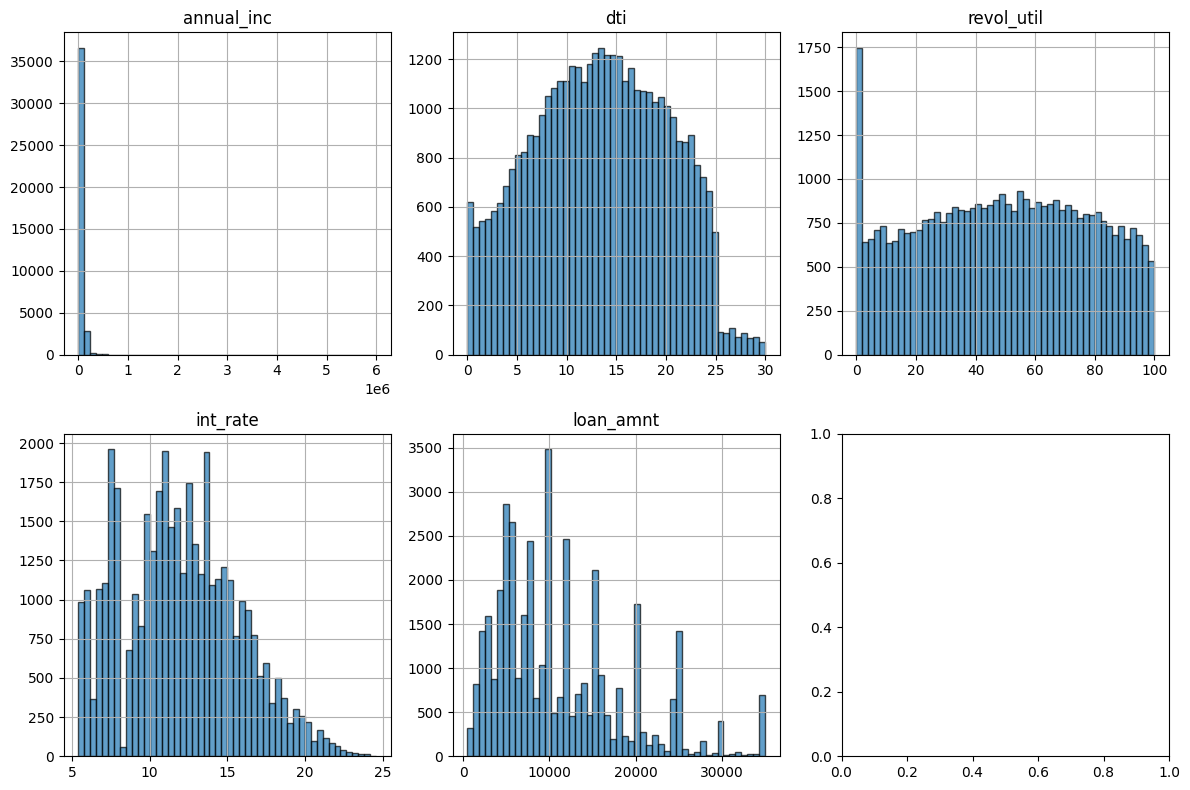

In [6]:
# Quick distribution plots (optional; comment out if no matplotlib)
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, col in zip(axes.flat, ["annual_inc", "dti", "revol_util", "int_rate", "loan_amnt", "fico_mid" if "fico_mid" in df.columns else "fico_low"]):
        if col in df.columns:
            df[col].dropna().hist(ax=ax, bins=50, edgecolor="black", alpha=0.7)
            ax.set_title(col)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plots skipped: {e}")

## 5. Build 15 PD features (common_features)

We use the shared module so that the same feature definitions are used in training notebooks and in the eval pipeline (benchmark parquet query text → features).

In [7]:
from credit_risk.feature_engineering.common_features import (
    build_features_from_dataframe,
    get_feature_names,
)

X_raw = df.copy()
X_feat = build_features_from_dataframe(X_raw)
feature_names = get_feature_names()
print("15 features:", feature_names)
print(X_feat.describe().round(3).to_string())

15 features: ['dti_ratio', 'installment_to_income', 'fico_mid', 'revol_util_pct', 'loan_to_income', 'grade_num', 'emp_months', 'delinq_flag', 'inq_6m', 'acc_util', 'int_rate_high', 'revol_bal_log', 'fico_subprime', 'dti_high', 'composite_risk']
       dti_ratio  installment_to_income  fico_mid  revol_util_pct  loan_to_income  grade_num  emp_months  delinq_flag     inq_6m   acc_util  int_rate_high  revol_bal_log  fico_subprime   dti_high  composite_risk
count  39786.000              39786.000       0.0       39736.000       39786.000  39786.000   38708.000    39786.000  39786.000  39786.000      39786.000      39786.000        39786.0  39786.000       39786.000
mean      13.318                  0.005       NaN           0.489           0.188      2.580      61.115        0.109      0.869      0.471          0.215          8.700            0.0      0.189           0.432
std        6.678                  0.003       NaN           0.283           0.116      1.388      40.905        0.311  

## 6. Fill NaN and attach target

Fill remaining NaNs in features with median (or 0 for flags) so that tree and quantum models receive numeric inputs only.

In [8]:
for c in X_feat.columns:
    if X_feat[c].isna().any():
        if "flag" in c or "high" in c or "subprime" in c:
            X_feat[c] = X_feat[c].fillna(0.0)
        else:
            X_feat[c] = X_feat[c].fillna(X_feat[c].median())

X_feat["default"] = df["default"].values
out_path = OUTPUT_DIR / "lendingclub_engineered.parquet"
X_feat.to_parquet(out_path, index=False)
print(f"Saved engineered dataset to {out_path} ({len(X_feat):,} rows, {len(feature_names)} features + target).")

c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Saved engineered dataset to C:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\credit_risk_pd\LendingClub\processed\lendingclub_engineered.parquet (39,786 rows, 15 features + target).


## 7. Summary

- Target: **default** (1 = Charged Off, 0 = Fully Paid).
- Outlier study: caps applied on `annual_inc`, `revol_util`, `dti`, `open_acc`, `inq_last_6mths`.
- 15 features produced by `common_features`; NaNs filled; saved to `data/credit_risk_pd/LendingClub/processed/lendingclub_engineered.parquet`.
- Downstream notebooks (XGBoost, QNN/VQC/QSVM) should load this parquet and use the same `feature_names` for train/val split and model training.